# Test the classical (visible-light) vein pipeline on Kaggle -- before touching the Pi
This notebook does NOT need a camera or a GPU. It runs the same code the Pi will run
(`vein_postprocess.py` + `vein_classical.py`) on images or a video you upload as a Kaggle
dataset, so you can check detection quality and tune thresholds first.

**Settings needed:** Accelerator = None is fine (CPU only). Internet = off is fine too.

In [1]:
!pip install -q scikit-image scipy opencv-python-headless

## 1. Write the two shared modules (identical to the files you already have)

In [2]:
%%writefile vein_postprocess.py
"""
Vein post-processing: probability map -> clean mask -> skeleton -> junctions
-> best straight/thick segment -> needle target point (+ direction).
Pure numpy / scipy / scikit-image / OpenCV (no deep-learning dependency).
"""
import cv2
import numpy as np
from dataclasses import dataclass
from scipy import ndimage as ndi
from skimage.morphology import skeletonize

K8 = np.ones((3, 3), int)
K8[1, 1] = 0


@dataclass
class Target:
    x: int
    y: int
    width_px: float          # local vein diameter (2 x distance transform)
    direction: np.ndarray    # unit vector along the vein (dx, dy)
    dist_to_junction_px: float
    score: float


def clean_mask(prob, thr=0.5, min_area=80):
    m = (prob > thr).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    keep = np.zeros(n, bool)
    keep[1:] = stats[1:, cv2.CC_STAT_AREA] >= min_area          # drop tiny blobs (noise)
    m = keep[lab].astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    return m.astype(bool)


def _neighbours(skel):
    return ndi.convolve(skel.astype(int), K8, mode="constant") * skel


def prune_spurs(skel, spur_len=10, passes=2):
    """Remove short side-branches (skeleton 'hairs') that hang off a junction."""
    skel = skel.copy()
    for _ in range(passes):
        nb = _neighbours(skel)
        junc = skel & (nb >= 3)
        zone = cv2.dilate(junc.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        branches = skel & ~zone
        lab, n = ndi.label(branches, structure=np.ones((3, 3)))
        endpoints = skel & (nb == 1)
        zone_touch = cv2.dilate(zone.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        for i in range(1, n + 1):
            comp = lab == i
            if comp.sum() < spur_len and (comp & endpoints).any() and (comp & zone_touch).any():
                skel[comp] = False
        skel = skeletonize(skel)
    return skel


def analyse(prob, thr=0.5, min_area=80, spur_len=10, junction_pad=6):
    mask = clean_mask(prob, thr, min_area)
    dt = ndi.distance_transform_edt(mask)                 # radius at every vein pixel
    skel = prune_spurs(skeletonize(mask), spur_len)
    nb = _neighbours(skel)
    junctions = skel & (nb >= 3)                          # bifurcations / confluences
    endpoints = skel & (nb == 1)
    k = 2 * junction_pad + 1
    jzone = cv2.dilate(junctions.astype(np.uint8), np.ones((k, k), np.uint8)).astype(bool)
    segments, nseg = ndi.label(skel & ~jzone, structure=np.ones((3, 3)))
    dist_to_j = (ndi.distance_transform_edt(~junctions) if junctions.any()
                 else np.full(mask.shape, 1e6))
    return dict(mask=mask, dt=dt, skel=skel, junctions=junctions, endpoints=endpoints,
                segments=segments, nseg=nseg, dist_to_j=dist_to_j)


def _direction(pts, cy, cx, r=12):
    d = np.hypot(pts[:, 0] - cy, pts[:, 1] - cx)
    p = pts[d <= r].astype(float)
    if len(p) < 3:
        return np.array([1.0, 0.0])
    p -= p.mean(0)
    _, _, vt = np.linalg.svd(p, full_matrices=False)
    v = vt[0]                                             # (dy, dx)
    return np.array([v[1], v[0]])                         # -> (dx, dy)


def pick_target(a, min_len=25, min_width=4.0, safe_junction_px=15, end_margin=8):
    """Choose the best needle target on the best segment.
    score = width * straightness * length factor; pixel = widest point that is
    far from junctions and from the ends of the segment."""
    best = None
    for i in range(1, a["nseg"] + 1):
        ys, xs = np.nonzero(a["segments"] == i)
        L = len(ys)
        if L < min_len:
            continue
        pts = np.stack([ys, xs], 1)
        w = 2 * a["dt"][ys, xs]
        # straightness: 1.0 = straight line, lower = curvy
        s = np.linalg.svd(pts - pts.mean(0), compute_uv=False)
        straight = 1.0 if s[1] < 1e-6 else float(1 - min(s[1] / s[0], 1.0))
        # keep pixels away from junctions and from segment ends
        far_j = a["dist_to_j"][ys, xs] >= safe_junction_px
        ends = a["endpoints"][ys, xs]
        if ends.any():
            ey, ex = ys[ends], xs[ends]
            far_e = np.min(np.hypot(ys[:, None] - ey[None], xs[:, None] - ex[None]), 1) >= end_margin
        else:
            far_e = np.ones(L, bool)
        # smooth width along the segment to ignore single-pixel noise
        w_s = ndi.uniform_filter1d(w[np.argsort(ys * 10000 + xs)], 5)[np.argsort(np.argsort(ys * 10000 + xs))]
        ok = far_j & far_e & (w_s >= min_width)
        if not ok.any():
            continue
        idx = np.flatnonzero(ok)[np.argmax(w_s[ok])]
        seg_score = float(w_s[idx] * straight * min(L / 60.0, 1.0))
        if best is None or seg_score > best.score:
            best = Target(int(xs[idx]), int(ys[idx]), float(w_s[idx]),
                          _direction(pts, ys[idx], xs[idx]),
                          float(a["dist_to_j"][ys[idx], xs[idx]]), seg_score)
    return best


def draw(img_bgr, a, target, show_junctions=True):
    out = img_bgr.copy()
    out[a["skel"]] = (0, 255, 0)                          # green skeleton
    if show_junctions:
        for y, x in zip(*np.nonzero(a["junctions"])):
            cv2.circle(out, (int(x), int(y)), 3, (0, 165, 255), -1)   # orange = branch point
    if target is not None:
        c = (target.x, target.y)
        cv2.drawMarker(out, c, (0, 0, 255), cv2.MARKER_CROSS, 24, 2)  # red pointer
        tip = (int(c[0] + 30 * target.direction[0]), int(c[1] + 30 * target.direction[1]))
        cv2.arrowedLine(out, c, tip, (255, 0, 0), 1, tipLength=0.3)   # vein axis
        cv2.putText(out, f"TARGET: ({target.x}, {target.y})  w={target.width_px:.1f}px",
                    (c[0] + 12, c[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    return out


class TargetSmoother:
    """Video use: exponential smoothing + only report when stable."""
    def __init__(self, alpha=0.3, jump_px=25):
        self.alpha, self.jump, self.p = alpha, jump_px, None

    def update(self, t):
        if t is None:
            return None if self.p is None else tuple(map(int, self.p))
        q = np.array([t.x, t.y], float)
        if self.p is None or np.linalg.norm(q - self.p) > self.jump:
            self.p = q                                    # re-lock on a new vein
        else:
            self.p = (1 - self.alpha) * self.p + self.alpha * q
        return tuple(map(int, self.p))


Writing vein_postprocess.py


In [3]:
%%writefile vein_classical.py
"""
Classical (no deep learning) vein extraction for VISIBLE-LIGHT cameras.

Why this file exists: with a standard (IR-cut) Pi camera, veins are faint
grey/green ridges, not the dark NIR lines the earlier U-Net was trained on.
A vesselness (ridge) filter, restricted to skin and tuned per-frame, tracks
that faint signal far better than a network trained on a different domain.

Needs: opencv-python, numpy, scipy, scikit-image  (same as vein_postprocess.py)
"""
import cv2
import numpy as np
from skimage.filters import sato
from vein_postprocess import analyse, pick_target, draw, TargetSmoother   # reused as-is

WORK_W = 480          # vesselness runs at this width for speed, result is upscaled back


def skin_mask(bgr):
    """Rough hand silhouette in YCrCb, eroded inward so the bright rim of the
    hand (which always looks like a strong 'edge') is excluded from the ROI."""
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
    m = cv2.inRange(ycrcb, (0, 133, 77), (255, 180, 135))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((9, 9), np.uint8))
    n, lab, st, _ = cv2.connectedComponentsWithStats(m, 8)
    if n > 1:
        m = (lab == 1 + np.argmax(st[1:, cv2.CC_STAT_AREA])).astype(np.uint8) * 255
    m = cv2.erode(m, np.ones((25, 25), np.uint8))
    return m > 0


def enhance(bgr):
    """Green channel has the best vein/skin contrast in visible light on most
    skin tones (haemoglobin absorbs green more than red); CLAHE + bilateral
    lift local contrast while keeping vein edges (unlike a plain blur)."""
    g = cv2.split(bgr)[1]
    g = cv2.createCLAHE(2.0, (8, 8)).apply(g)
    return cv2.bilateralFilter(g, 9, 50, 50)


def vesselness(gray_full, roi_full):
    """Multi-scale ridge filter, computed small then upscaled (this is the
    slow step on a Pi CPU)."""
    h, w = gray_full.shape
    scale = WORK_W / w
    small = cv2.resize(gray_full, (WORK_W, int(h * scale)))
    v = sato(small.astype(np.float32) / 255, sigmas=np.arange(1.2, 4, 0.7), black_ridges=True)
    v = cv2.resize(v, (w, h))
    v = cv2.GaussianBlur(v, (0, 0), 0.8)
    v[~roi_full] = 0
    m = v.max()
    return v / m if m > 1e-6 else v


class FrameAverager:
    """Averages the last N grayscale frames to cut sensor noise. Only helps
    when the camera AND the hand are both still -- exactly your setup."""
    def __init__(self, n=6):
        self.n, self.buf = n, []

    def push(self, gray):
        self.buf.append(gray.astype(np.float32))
        self.buf = self.buf[-self.n:]
        return np.mean(self.buf, axis=0).astype(np.uint8)


def process(bgr, avg: FrameAverager, min_width_px=2.5):
    roi = skin_mask(bgr)
    if roi.sum() < 0.02 * roi.size:                      # no hand in frame
        return None, None, roi
    stable_gray = avg.push(enhance(bgr))
    prob = vesselness(stable_gray, roi)
    thr = max(float(np.percentile(prob[roi], 98.5)), 0.12)
    a = analyse(prob, thr=thr, min_area=60, spur_len=15, junction_pad=8)
    t = pick_target(a, min_len=30, min_width=min_width_px, safe_junction_px=12, end_margin=8)
    return a, t, roi


Writing vein_classical.py


## 2. Test on a single image
Upload a photo from your Pi camera as a Kaggle dataset (Add Input), then point `IMG_PATH`
at it. Use an OPEN, RELAXED hand with even lighting for the fairest test.

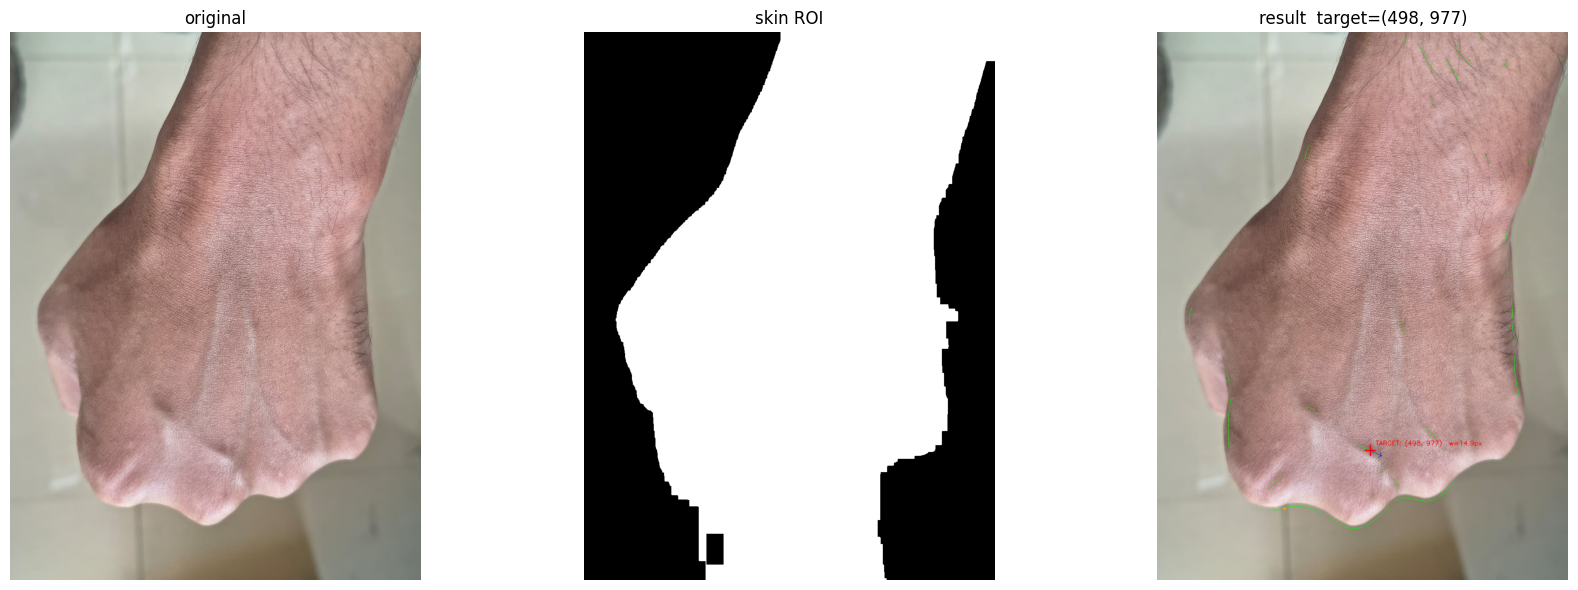

In [4]:
import cv2, matplotlib.pyplot as plt
from vein_classical import process, FrameAverager
from vein_postprocess import draw

IMG_PATH = "/kaggle/input/datasets/minhaj099/hand-img-phn/hand9.jpeg"     # <- change

bgr = cv2.imread(IMG_PATH)
avg = FrameAverager(n=1)          # a still photo has nothing to average over
a, t, roi = process(bgr, avg)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(roi, cmap="gray"); ax[1].set_title("skin ROI"); ax[1].axis("off")
if a is not None:
    out = draw(bgr, a, t)
    ax[2].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax[2].set_title(f"result  target={ (t.x, t.y) if t else None }")
else:
    ax[2].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ax[2].set_title("no hand detected -- check skin_mask")
ax[2].axis("off")
plt.tight_layout(); plt.show()

## 3. Test on several images at once
Point `IMG_DIR` at a folder of photos (e.g. different hands/lighting) to see how consistent it is.

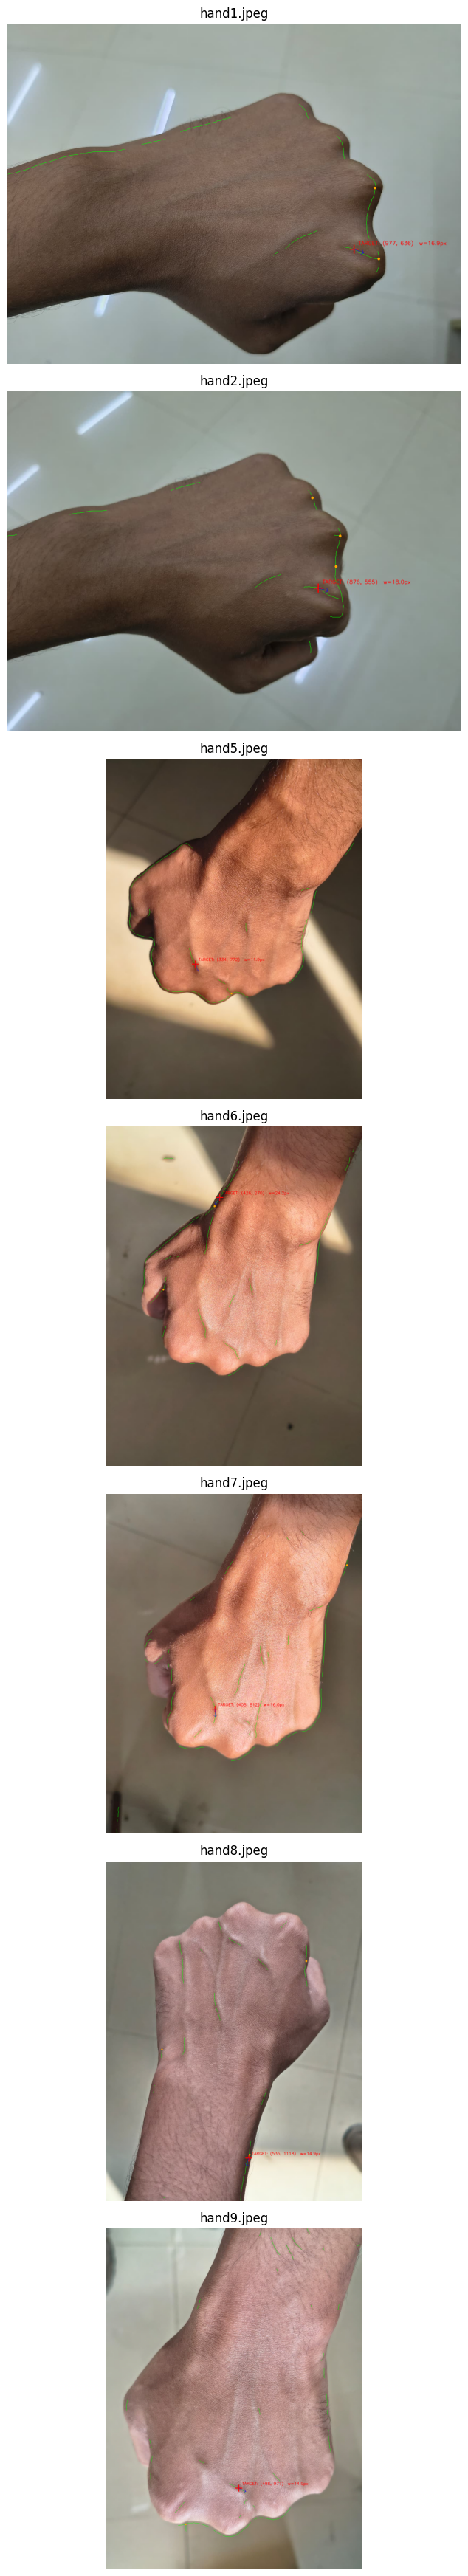

In [5]:
import glob
IMG_DIR = "/kaggle/input/datasets/minhaj099/hand-img-phn"     # <- change

paths = sorted(glob.glob(f"{IMG_DIR}/*.jpeg") + glob.glob(f"{IMG_DIR}/*.png"))[:8]
fig, ax = plt.subplots(len(paths), 1, figsize=(8, 5*len(paths)))
ax = [ax] if len(paths) == 1 else ax
for a_, p in zip(ax, paths):
    bgr = cv2.imread(p)
    seg, t, roi = process(bgr, FrameAverager(n=1))
    out = draw(bgr, seg, t) if seg is not None else bgr
    a_.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); a_.set_title(p.split("/")[-1]); a_.axis("off")
plt.tight_layout(); plt.show()

## 4. Test on a video (simulates the live Pi loop, frame averaging included)
Upload a short video recorded on the SAME Pi camera as a Kaggle dataset. This uses the
identical `process()` call and `FrameAverager` the Pi script uses, so if it looks good here,
it will behave the same way live.

In [6]:
VIDEO_PATH = "/kaggle/input/datasets/minhaj099/hand-vid-v3/hand_vid_v3.mp4"     # <- change
OUT_PATH = "/kaggle/working/vein_classical_out2.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
W, H, FPS = int(cap.get(3)), int(cap.get(4)), cap.get(cv2.CAP_PROP_FPS) or 25
out = cv2.VideoWriter(OUT_PATH, cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))

avg = FrameAverager(n=6)          # same window as the Pi script
targets = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    seg, t, roi = process(frame, avg)
    vis = draw(frame, seg, t) if seg is not None else frame
    out.write(vis)
    if t:
        targets.append((t.x, t.y))
cap.release(); out.release()
print(f"processed video -> {OUT_PATH}")
print(f"target found on {len(targets)} frames")

processed video -> /kaggle/working/vein_classical_out2.mp4
target found on 349 frames


## 5. Watch the output video
Kaggle can preview it in the Output panel, or play it inline here.

In [7]:
from IPython.display import Video
Video(OUT_PATH, embed=True, width=640)

## 6. Tuning cheat-sheet (edit these in `vein_classical.py`, then re-run the `%%writefile` cell above)
| Symptom | What to change |
|---|---|
| Picks up skin creases / knuckles | raise the `98.5` percentile in `process()`, or raise `min_width_px` |
| Misses real, visible veins | lower the percentile, or widen `sigmas` in `vesselness()` |
| ROI misses part of the hand | loosen the YCrCb bounds in `skin_mask()`, or reduce the erosion kernel |
| Target jitters between frames (video) | raise `FrameAverager(n=...)`, or raise `TargetSmoother(jump_px=...)` in the Pi script |

Once this looks right on Kaggle, copy the same `vein_classical.py` (and `vein_postprocess.py`)
onto the Pi unchanged -- `pi_live_classical.py` imports them exactly as this notebook does.